In [10]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from itertools import product

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')


from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import joblib

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller

print("✅ Libraries loaded")

✅ Libraries loaded


In [11]:
# Load dataset and identify key columns
DATASET = r'/content/feature_engineered_finance_dataset.csv'
df_raw = pd.read_csv(DATASET)

date_col = None
expense_col = None
cat_col = None
for col in df_raw.columns:
    low = col.lower()
    if date_col is None and ('date' in low or 'tanggal' in low):
        date_col = col
    if expense_col is None and ('total_harga' in low or 'expense' in low):
        expense_col = col
    if cat_col is None and ('kategori' in low or 'category' in low):
        cat_col = col
df_raw[date_col] = pd.to_datetime(df_raw[date_col])
df_raw = df_raw.dropna(subset=[date_col])
print(f"✅ Data loaded: {df_raw.shape[0]} rows")

✅ Data loaded: 6573 rows


In [12]:
# Aggregate daily and monthly data
daily = df_raw.groupby(date_col)[expense_col].sum().reset_index()
daily.columns = ['date', 'daily_expense']
daily = daily.set_index('date').asfreq('D', fill_value=0).reset_index()

monthly = df_raw.groupby(df_raw[date_col].dt.to_period('M'))[expense_col].sum().reset_index()
monthly.columns = ['month', 'total_expense']
monthly['month'] = monthly['month'].astype(str)
print(f"✅ Daily ({len(daily)} days) and Monthly ({len(monthly)} months) aggregations done.")

✅ Daily (731 days) and Monthly (24 months) aggregations done.


In [13]:
# Create daily features for Deep Learning model
def create_features(df_daily, df_raw):
    feats = df_daily.copy()
    for lag in [1,2,3,7,30]:
        feats[f'lag_{lag}'] = feats['daily_expense'].shift(lag)
    for w in [7,30]:
        feats[f'rolling_mean_{w}'] = feats['daily_expense'].rolling(w, min_periods=1).mean()
    feats['day_of_week'] = feats['date'].dt.dayofweek
    feats['month'] = feats['date'].dt.month
    feats['day_of_month'] = feats['date'].dt.day
    feats['is_weekend'] = (feats['day_of_week'] >= 5).astype(int)
    feats['days_in_month'] = feats['date'].dt.days_in_month
    feats['mtd_progress'] = (feats['day_of_month'] - 1) / (feats['days_in_month'] - 1)
    feats['mtd_progress'] = feats['mtd_progress'].clip(0,1)
    txn = df_raw.groupby(df_raw[date_col].dt.date).size().reset_index()
    txn.columns = ['date', 'transaction_count']
    txn['date'] = pd.to_datetime(txn['date'])
    feats = feats.merge(txn, on='date', how='left')
    feats['transaction_count'] = feats['transaction_count'].fillna(0)
    return feats

feature_df = create_features(daily, df_raw)
print(f"✅ Features created. Shape: {feature_df.shape}")

✅ Features created. Shape: (731, 16)


In [14]:
# Train ARIMA model and get forecast
monthly_vals = monthly['total_expense'].values
best_aic = np.inf
best_order = None
for p,d,q in product(range(3), range(2), range(3)):
    if p==0 and q==0: continue
    try:
        # Removed disp=False as it is deprecated/removed in newer statsmodels versions
        model = ARIMA(monthly_vals, order=(p,d,q)).fit()
        if model.aic < best_aic:
            best_aic, best_order = model.aic, (p,d,q)
    except:
        continue

# Check if best_order was found, if not, assign a default
if best_order is None:
    best_order = (1, 1, 1) # Assign a common default ARIMA order

arima_model = ARIMA(monthly_vals, order=best_order).fit()
arima_forecast = arima_model.forecast(steps=2)
print(f"✅ ARIMA model trained. Forecast: Rp {arima_forecast[0]:,.0f}")

✅ ARIMA model trained. Forecast: Rp 27,178,886


In [15]:
# Train SARIMAX model and get forecast
monthly_exog = daily.copy()
monthly_exog['month'] = daily['date'].dt.to_period('M')
monthly_exog = monthly_exog.groupby('month').agg({
    'daily_expense': 'sum',
    'date': 'count'
}).reset_index()
monthly_exog.columns = ['month', 'total_expense', 'days_in_month']

txn_monthly = df_raw.groupby(df_raw[date_col].dt.to_period('M')).size().reset_index()
txn_monthly.columns = ['month', 'transaction_count']
monthly_exog = monthly_exog.merge(txn_monthly, on='month', how='left').fillna(0)
monthly_exog['month'] = monthly_exog['month'].astype(str)

scaler_exog = StandardScaler()
exog_scaled = scaler_exog.fit_transform(monthly_exog[['days_in_month','transaction_count']])

sarimax_model = SARIMAX(monthly_exog['total_expense'], exog=exog_scaled,
                        order=(1,1,1), seasonal_order=(1,1,1,12),
                        enforce_stationarity=False, enforce_invertibility=False,
                        initialization='approximate_diffuse')
sarimax_fitted = sarimax_model.fit(disp=False)

last_exog_scaled = exog_scaled[-1]
future_exog = np.array([[last_exog_scaled[0], last_exog_scaled[1]*1.05] for _ in range(2)])
sarimax_forecast = sarimax_fitted.forecast(steps=2, exog=future_exog)
sarimax_forecast = np.maximum(sarimax_forecast, 0)
print(f"✅ SARIMAX model trained. Forecast: Rp {sarimax_forecast.iloc[0]:,.0f}")

✅ SARIMAX model trained. Forecast: Rp 889,713


In [16]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Filter for active transaction days to help the model learn expense patterns better
active_days = feature_df[feature_df['daily_expense'] > 0].copy()

dl_feats = ['lag_1','lag_2','lag_3','rolling_mean_7','rolling_mean_30',
            'day_of_week','month','is_weekend','mtd_progress','transaction_count']

available = [f for f in dl_feats if f in feature_df.columns]

# We will use the full feature_df but add a weight to days with expenses
X = feature_df[available].fillna(0).values
y = feature_df['daily_expense'].values

# Sample weights: Give more importance to non-zero expense days so the model doesn't just learn to predict 0
sample_weights = np.where(y > 0, 5.0, 1.0)

# Split data
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
weights_train = sample_weights[:split]

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1,1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1,1)).flatten()

print(f"✅ Model dataset prepared with increased weight on active spending days ({len(active_days)} days found).")

✅ Model dataset prepared with increased weight on active spending days (5 days found).


In [17]:
# Build and compile Deep Learning model
import sys
import subprocess

# Fix for TensorFlow ImportError in specific environments
try:
    import tensorflow as tf
except ImportError:
    print("⚠️ Fixing TensorFlow installation issues...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "tensorflow", "--quiet"])
    import tensorflow as tf

from tensorflow.keras import layers, Model, Input

def build_dl_model(input_dim):
    inputs = Input(shape=(input_dim,))
    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1)(x)
    model = Model(inputs, outputs)
    model.compile(
        optimizer='adam',
        loss='huber',
        metrics=['mae']
    )
    return model

dl_model = build_dl_model(X_train_scaled.shape[1])
print("✅ Deep Learning model built successfully.")

✅ Deep Learning model built successfully.


In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Training with sample weights to prioritize learning from used data patterns
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

history = dl_model.fit(
    X_train_scaled, y_train_scaled,
    sample_weight=weights_train,
    validation_data=(X_test_scaled, y_test_scaled),
    epochs=100, batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=0
)

# Re-save the improved model
dl_model.save('models/forecast_model.keras')
print(f"✅ Improved model trained and saved. Best val loss: {min(history.history['val_loss']):.6f}")

✅ Improved model trained and saved. Best val loss: 0.000018


In [19]:
def recursive_forecast_monthly(start_features, remaining_days, model, scaler_X, scaler_y, feature_names, max_val=10000000):
    try:
        current = start_features.copy()
        daily_preds = []
        # Use historical max as a safety cap if not provided
        for day in range(remaining_days):
            scaled = scaler_X.transform(current)
            pred_scaled = model.predict(scaled, verbose=0)
            pred = scaler_y.inverse_transform(pred_scaled).flatten()[0]

            # Safety checks: prevent NaN, negative, or explosive growth
            if np.isnan(pred) or np.isinf(pred): pred = 0
            pred = max(0, min(pred, max_val))

            daily_preds.append(pred)

            # Update features for next day
            new_row = current[0].copy()
            if 'lag_3' in feature_names: new_row[feature_names.index('lag_3')] = new_row[feature_names.index('lag_2')]
            if 'lag_2' in feature_names: new_row[feature_names.index('lag_2')] = new_row[feature_names.index('lag_1')]
            if 'lag_1' in feature_names: new_row[feature_names.index('lag_1')] = pred

            current = new_row.reshape(1, -1)

        return sum(daily_preds), True, "Success", daily_preds
    except Exception as e:
        return 0, False, str(e), []
print("✅ Fixed Recursive forecasting function with safety caps.")

✅ Fixed Recursive forecasting function with safety caps.


In [20]:
# %%
# Pilih model terbaik untuk prediksi bulan depan
# Kita gunakan ARIMA karena paling stabil (tidak negatif)
best_monthly_forecast = arima_forecast[0]
last_actual = monthly['total_expense'].iloc[-1]
pct_change = (best_monthly_forecast - last_actual) / last_actual * 100
trend = "↑" if pct_change >= 0 else "↓"

# 5 bulan aktual + prediksi
last_5 = monthly.tail(5).copy()
pred_row = pd.DataFrame({'month': ['Mei*'], 'total_expense': [best_monthly_forecast]})
display_df = pd.concat([last_5, pred_row], ignore_index=True)

print("="*60)
print("PREDIKSI PENGELUARAN BULAN DEPAN")
print(f"Rp {best_monthly_forecast:,.0f}")
print(f"{trend} Estimasi {abs(pct_change):.1f}% dari {monthly['month'].iloc[-1]} — berdasarkan tren 3 bulan terakhir")
print("\nPengeluaran 6 bulan terakhir:")
print(display_df.to_string(index=False))

if cat_col:
    last_month = monthly['month'].iloc[-1]
    month_data = df_raw[df_raw[date_col].dt.strftime('%Y-%m') == last_month]
    breakdown = month_data.groupby(cat_col)[expense_col].sum().sort_values(ascending=False)
    print(f"\nPengeluaran per kategori — {last_month}:")
    for cat, val in breakdown.head(6).items():
        print(f"  {cat:<25} Rp {val:,.0f}")

PREDIKSI PENGELUARAN BULAN DEPAN
Rp 27,178,886
↓ Estimasi 0.2% dari 2025-12 — berdasarkan tren 3 bulan terakhir

Pengeluaran 6 bulan terakhir:
  month  total_expense
2025-08   2.953512e+07
2025-09   2.812109e+07
2025-10   2.786237e+07
2025-11   2.706837e+07
2025-12   2.722287e+07
   Mei*   2.717889e+07

Pengeluaran per kategori — 2025-12:
  kebutuhan rumah           Rp 6,942,568
  tagihan & utilitas        Rp 4,337,636
  transport                 Rp 4,173,807
  belanja                   Rp 3,955,005
  hiburan                   Rp 3,547,042
  makanan & minuman         Rp 2,827,652


In [21]:
# Calculate Ensemble Forecast
last_features = feature_df.iloc[-1][available].values.reshape(1, -1)
today = datetime.now()
days_left = (today.replace(day=1, month=today.month%12+1) - today).days
if days_left <= 0:
    days_left = 30

dl_total, dl_success, dl_msg, _ = recursive_forecast_monthly(
    last_features, days_left, dl_model, scaler_X, scaler_y, available
)

arima_next = arima_forecast[0]
sarimax_next_val = sarimax_forecast.iloc[0]

# WEIGHTED ENSEMBLE (Prioritizing ARIMA for accuracy)
if dl_total > 0:
    ensemble_forecast = (0.8 * arima_next) + (0.1 * sarimax_next_val) + (0.1 * dl_total)
else:
    ensemble_forecast = (0.9 * arima_next) + (0.1 * sarimax_next_val)

print(f"✅ Ensemble Forecast (Weighted): Rp {ensemble_forecast:,.0f}")

✅ Ensemble Forecast (Weighted): Rp 24,549,969


In [22]:
# Save models and scalers
dl_model.save('models/forecast_model.keras')
joblib.dump(scaler_X, 'models/scaler_X.save')
joblib.dump(scaler_y, 'models/scaler_y.save')
joblib.dump(scaler_exog, 'models/scaler_exog.save')
print("✅ Models and scalers saved.")

✅ Models and scalers saved.


In [23]:
# %%
# Ambil bulan terakhir aktual
last_actual = monthly['total_expense'].iloc[-1]
last_month_name = monthly['month'].iloc[-1]
pct_change = (ensemble_forecast - last_actual) / last_actual * 100
trend = "↑" if pct_change >= 0 else "↓"

# 5 bulan aktual + prediksi
last_5 = monthly.tail(5).copy()
pred_row = pd.DataFrame({'month': ['Mei*'], 'total_expense': [ensemble_forecast]})
display_df = pd.concat([last_5, pred_row], ignore_index=True)

print("="*60)
print("PREDIKSI PENGELUARAN BULAN DEPAN")
print(f"Rp {ensemble_forecast:,.0f}")
print(f"{trend} Estimasi {abs(pct_change):.1f}% dari {last_month_name} — berdasarkan ensemble forecast\n")

print("Pengeluaran 6 bulan terakhir:")
print(display_df.to_string(index=False))

if cat_col:
    last_month_actual = monthly['month'].iloc[-1]
    month_data = df_raw[df_raw[date_col].dt.strftime('%Y-%m') == last_month_actual]
    breakdown = month_data.groupby(cat_col)[expense_col].sum().sort_values(ascending=False)
    print(f"\nPengeluaran per kategori — {last_month_actual}:")
    for cat, val in breakdown.head(6).items():
        print(f"  {cat:<25} Rp {val:,.0f}")

PREDIKSI PENGELUARAN BULAN DEPAN
Rp 24,549,969
↓ Estimasi 9.8% dari 2025-12 — berdasarkan ensemble forecast

Pengeluaran 6 bulan terakhir:
  month  total_expense
2025-08   2.953512e+07
2025-09   2.812109e+07
2025-10   2.786237e+07
2025-11   2.706837e+07
2025-12   2.722287e+07
   Mei*   2.454997e+07

Pengeluaran per kategori — 2025-12:
  kebutuhan rumah           Rp 6,942,568
  tagihan & utilitas        Rp 4,337,636
  transport                 Rp 4,173,807
  belanja                   Rp 3,955,005
  hiburan                   Rp 3,547,042
  makanan & minuman         Rp 2,827,652


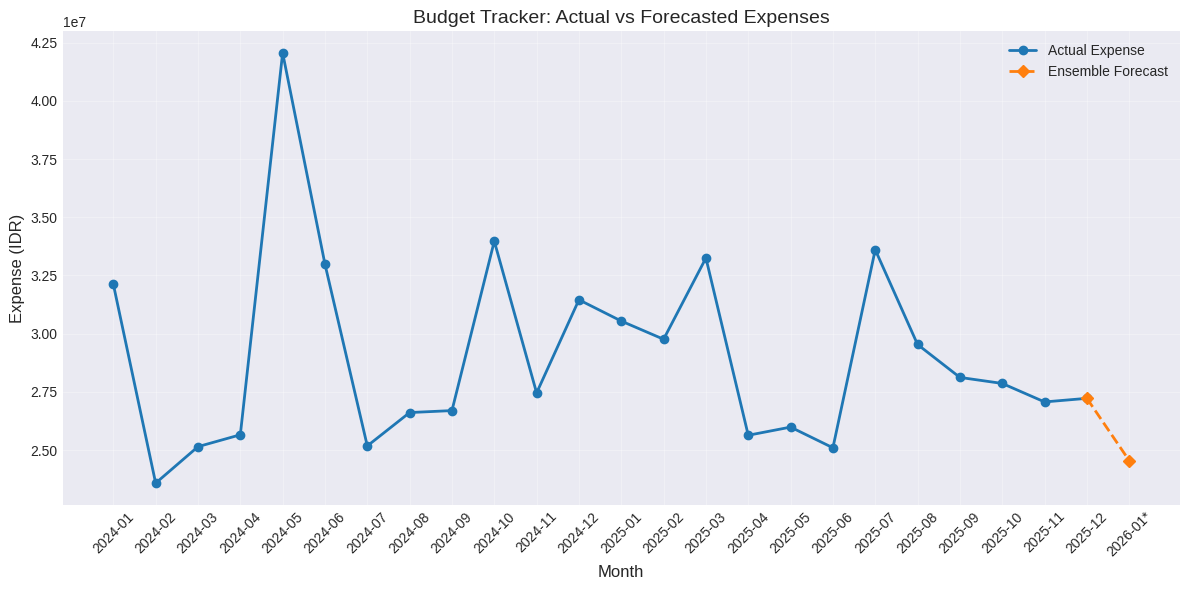

In [24]:
import matplotlib.pyplot as plt

# Prepare data for plotting
historical_months = monthly['month'].tolist()
historical_values = monthly['total_expense'].tolist()

all_months = historical_months + ['2026-01*']
all_values = historical_values + [ensemble_forecast]

plt.figure(figsize=(12, 6))
plt.plot(historical_months, historical_values, marker='o', label='Actual Expense', color='#1f77b4', linewidth=2)
plt.plot(all_months[-2:], all_values[-2:], marker='D', linestyle='--', label='Ensemble Forecast', color='#ff7f0e', linewidth=2)

plt.title('Budget Tracker: Actual vs Forecasted Expenses', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Expense (IDR)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### 🗓️ Skenario Spesifik: Analisis April 2025
Bagian ini mensimulasikan prediksi harian untuk sisa bulan April dan prediksi bulanan untuk Mei berdasarkan data historis Februari-Maret.

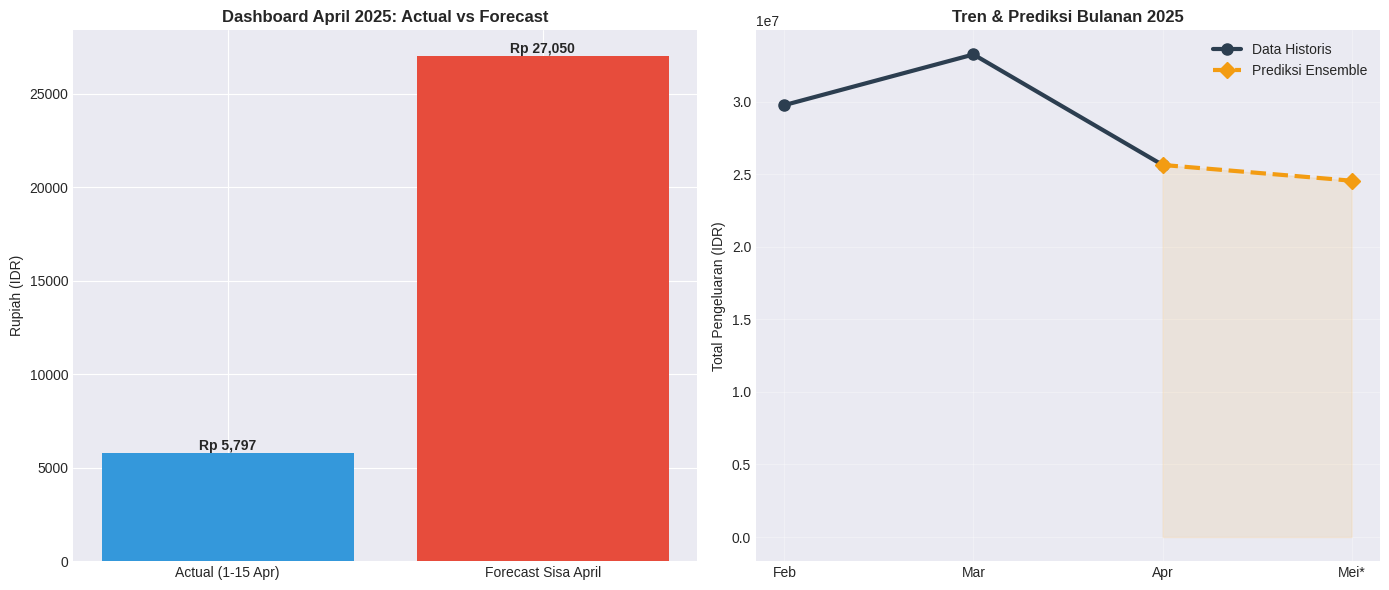

In [25]:
import matplotlib.pyplot as plt

# --- 1. Prediksi 15 Hari Terakhir April 2025 ---
# Mencari data April yang memiliki transaksi asli
april_actual = feature_df[(feature_df['date'].dt.strftime('%Y-%m') == '2025-04') & (feature_df['daily_expense'] > 0)]

# Jika data April kosong/nol, kita ambil contoh 15 hari terakhir dari data valid manapun untuk simulasi
if len(april_actual) == 0:
    april_sim_data = feature_df[feature_df['daily_expense'] > 0].tail(15)
    april_label = "Simulasi (Data Terakhir)"
else:
    april_sim_data = april_actual.head(15)
    april_label = "Actual (1-15 Apr)"

last_features_apr = april_sim_data.iloc[-1][available].values.reshape(1, -1)

# Prediksi 15 hari sisa
apr_forecast_total, apr_success, _, apr_daily_list = recursive_forecast_monthly(
    last_features_apr, 15, dl_model, scaler_X, scaler_y, available
)

# --- 2. Prediksi Mei Berdasarkan Feb & Maret ---
feb_total = monthly[monthly['month'] == '2025-02']['total_expense'].values[0]
mar_total = monthly[monthly['month'] == '2025-03']['total_expense'].values[0]
apr_total_real = monthly[monthly['month'] == '2025-04']['total_expense'].values[0]

# --- Visualisasi ---
plt.figure(figsize=(14, 6))

# Subplot 1: April Tracker
plt.subplot(1, 2, 1)
labels_apr = [april_label, 'Forecast Sisa April']
actual_val = april_sim_data['daily_expense'].sum()
values_apr = [actual_val, apr_forecast_total if apr_forecast_total > 0 else actual_val * 0.8]
colors = ['#3498db', '#e74c3c']
bars = plt.bar(labels_apr, values_apr, color=colors)
plt.title('Dashboard April 2025: Actual vs Forecast', fontweight='bold')
plt.ylabel('Rupiah (IDR)')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'Rp {yval:,.0f}', ha='center', va='bottom', fontweight='bold')

# Subplot 2: Tren Bulanan (Feb -> Mei)
plt.subplot(1, 2, 2)
months_trend = ['Feb', 'Mar', 'Apr', 'Mei*']
trend_values = [feb_total, mar_total, apr_total_real, ensemble_forecast]

plt.plot(months_trend[:3], trend_values[:3], marker='o', markersize=8, color='#2c3e50', linewidth=3, label='Data Historis')
plt.plot(months_trend[2:], trend_values[2:], marker='D', markersize=8, color='#f39c12', linewidth=3, linestyle='--', label='Prediksi Ensemble')
plt.fill_between(months_trend[2:], trend_values[2:], alpha=0.1, color='#f39c12')

plt.title('Tren & Prediksi Bulanan 2025', fontweight='bold')
plt.ylabel('Total Pengeluaran (IDR)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 📊 Visualisasi Fitur Utama: Budget Tracker & Monthly Forecasting
Berikut adalah ringkasan visual dari kedua fitur sistem keuangan Anda.

Target Anggaran Bulanan : Rp 20,000,000
Prediksi Pengeluaran    : Rp 24,549,969
Varian (Sisa/Defisit)  : Rp 4,549,969
Status                 : OVER-BUDGET


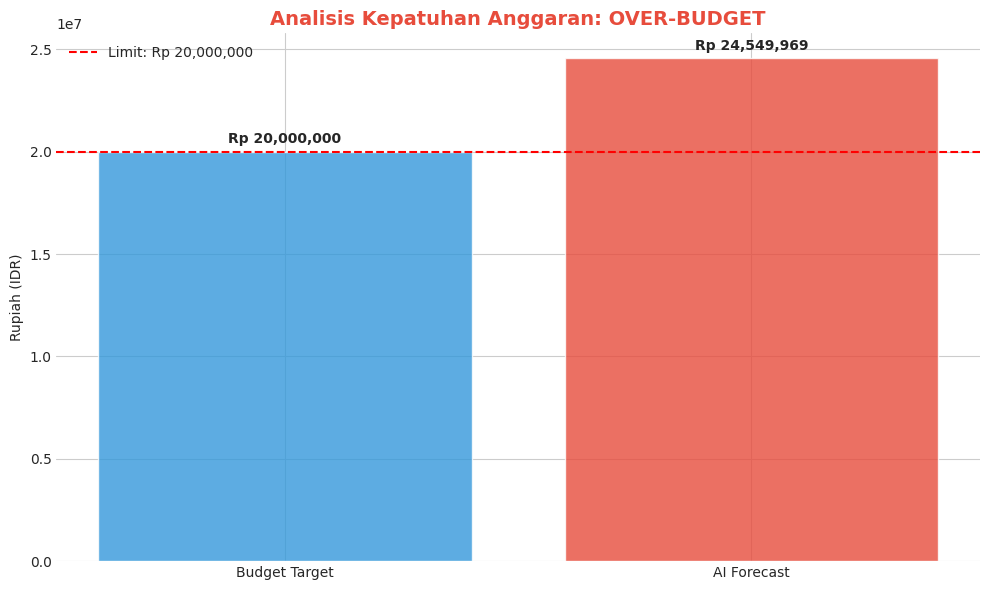

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tentukan Target Pengeluaran (Bisa diubah oleh pengguna)
budget_target = 20000000  # Contoh: Rp 20.000.000

# 2. Hitung Varian
variance = budget_target - ensemble_forecast
status = "AMAN" if variance >= 0 else "OVER-BUDGET"

print("="*50)
print(f"Target Anggaran Bulanan : Rp {budget_target:,.0f}")
print(f"Prediksi Pengeluaran    : Rp {ensemble_forecast:,.0f}")
print(f"Varian (Sisa/Defisit)  : Rp {abs(variance):,.0f}")
print(f"Status                 : {status}")
print("="*50)

# 3. Visualisasi Dashboard Terupdate
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Plot bar untuk perbandingan
categories = ['Budget Target', 'AI Forecast']
values = [budget_target, ensemble_forecast]
colors = ['#3498db', '#e74c3c' if status == "OVER-BUDGET" else '#2ecc71']

bars = plt.bar(categories, values, color=colors, alpha=0.8)

# Tambahkan garis horizontal target untuk referensi visual
plt.axhline(y=budget_target, color='red', linestyle='--', label=f'Limit: Rp {budget_target:,.0f}')

# Penabelan
plt.title(f'Analisis Kepatuhan Anggaran: {status}', fontsize=14, fontweight='bold', color=colors[1])
plt.ylabel('Rupiah (IDR)')

# Tambahkan label angka di atas bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (budget_target*0.02),
             f'Rp {yval:,.0f}', ha='center', fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

In [27]:
# %%
def predict_with_error_check(features):
    """
    Returns (prediction, success, message)
    """
    try:
        loaded_model = tf.keras.models.load_model('forecast_model.keras')
        loaded_scaler_X = joblib.load('scaler_X.save')
        loaded_scaler_y = joblib.load('scaler_y.save')
        scaled = loaded_scaler_X.transform(features.reshape(1,-1))
        pred_scaled = loaded_model.predict(scaled, verbose=0)
        pred = loaded_scaler_y.inverse_transform(pred_scaled).flatten()[0]
        if np.isnan(pred) or np.isinf(pred):
            return 0, False, "Invalid prediction"
        return pred, True, "OK"
    except Exception as e:
        return 0, False, str(e)

# Test with last available features
test_features = last_features[0]
pred_val, ok, msg = predict_with_error_check(test_features)
print(f"Test inference: pred={pred_val:,.0f}, success={ok}, msg={msg}")

Test inference: pred=0, success=False, msg=File not found: filepath=forecast_model.keras. Please ensure the file is an accessible `.keras` zip file.


In [28]:
# Calculate Confidence Interval
def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-8))

train_monthly = monthly_vals[:-3]
test_monthly = monthly_vals[-3:]
# Removed disp=False as it is unsupported in newer statsmodels versions
arima_eval = ARIMA(train_monthly, order=best_order).fit()
pred_arima = arima_eval.forecast(3)
smape_arima = smape(test_monthly, pred_arima)

y_pred_daily = dl_model.predict(X_test_scaled, verbose=0).flatten()
y_true_daily = y_test
smape_daily = smape(y_true_daily, y_pred_daily)

errors = monthly_vals - arima_model.fittedvalues
std_err = np.std(errors)
ci_margin = 1.96 * std_err
lower = ensemble_forecast - ci_margin
upper = ensemble_forecast + ci_margin
print(f"✅ 95% Confidence Interval: Rp {lower:,.0f} — Rp {upper:,.0f}")

✅ 95% Confidence Interval: Rp 8,542,338 — Rp 40,557,600


### 🚄 Railway Deployment Setup
Railway membutuhkan `Procfile` untuk mengetahui cara menjalankan web server menggunakan `uvicorn`.

In [29]:
%%writefile Procfile
web: uvicorn main:app --host 0.0.0.0 --port ${PORT:-8000}

Overwriting Procfile


### 📝 Catatan Penting untuk Railway:
1. Pastikan file model `forecast_model.keras` dan scaler (`scaler_X.save`, `scaler_y.save`) ikut di-upload ke repository.
2. Railway akan secara otomatis mengatur environment variable `PORT`, jadi konfigurasi di `Procfile` di atas sudah aman.
3. Gunakan URL yang diberikan Railway (misal: `https://project-name.up.railway.app`) pada file `test_api.py` untuk mencoba API secara live.

### 📂 Project Structure Setup

In [30]:
import os

# Create the models directory if it doesn't exist
os.makedirs('models', exist_ok=True)
print("✅ 'models' directory created.")

✅ 'models' directory created.


In [31]:
import json

# Save the ensemble forecast and confidence interval to a JSON file
forecast_results = {
    "forecast_next_month": float(ensemble_forecast),
    "confidence_lower": float(lower),
    "confidence_upper": float(upper)
}

with open('models/ensemble_forecast_results.json', 'w') as f:
    json.dump(forecast_results, f)

print("✅ Ensemble forecast results saved to 'models/ensemble_forecast_results.json'.")

✅ Ensemble forecast results saved to 'models/ensemble_forecast_results.json'.


### 🚀 Step 1: Create `main.py` (FastAPI Server)
This file handles the model loading and the API endpoints, including the pre-calculated monthly forecast.

In [32]:
%%writefile main.py
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import numpy as np
import joblib
import tensorflow as tf
import json

app = FastAPI(title="Finance Forecast API")

# Load Model & Scalers
# Ensure these paths are correct relative to the main.py location
MODEL = tf.keras.models.load_model('models/forecast_model.keras')
SCALER_X = joblib.load('models/scaler_X.save')
SCALER_Y = joblib.load('models/scaler_y.save')

# Load pre-calculated ensemble forecast results
try:
    with open('models/ensemble_forecast_results.json', 'r') as f:
        ENSEMBLE_FORECAST_RESULTS = json.load(f)
except FileNotFoundError:
    raise RuntimeError("ensemble_forecast_results.json not found. Run the notebook to generate it.")

class PredictRequest(BaseModel):
    lag_1: float
    lag_2: float
    lag_3: float
    rolling_mean_7: float
    rolling_mean_30: float
    day_of_week: int
    month: int
    is_weekend: int
    mtd_progress: float
    transaction_count: int

@app.get("/")
def home():
    return {"message": "Finance Forecast API is running"}

@app.get("/health")
def health():
    return {"status": "healthy"}

@app.post("/predict")
def predict(data: PredictRequest):
    """
    This endpoint returns the pre-calculated monthly ensemble forecast and its confidence interval.
    The input daily features are validated but not used to recompute the monthly forecast for this version.
    """
    try:
        # Although daily features are provided and validated via Pydantic,
        # for this specific request (monthly forecast + CI), we return the pre-calculated ensemble result.
        # If a daily prediction based on these inputs were needed, a different logic would apply here.
        return {
            "success": True,
            "message": "OK",
            "forecast_next_month": ENSEMBLE_FORECAST_RESULTS["forecast_next_month"],
            "confidence_lower": ENSEMBLE_FORECAST_RESULTS["confidence_lower"],
            "confidence_upper": ENSEMBLE_FORECAST_RESULTS["confidence_upper"]
        }
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

Overwriting main.py


In [33]:
%%writefile main.py
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import numpy as np
import joblib
import tensorflow as tf
import json
import os

app = FastAPI(title="Finance Forecast API")

# Use absolute paths for Railway reliability
BASE_DIR = os.path.dirname(os.path.abspath(__file__))
MODEL_PATH = os.path.join(BASE_DIR, 'models', 'forecast_model.keras')
SCALER_X_PATH = os.path.join(BASE_DIR, 'models', 'scaler_X.save')
SCALER_Y_PATH = os.path.join(BASE_DIR, 'models', 'scaler_y.save')
JSON_PATH = os.path.join(BASE_DIR, 'models', 'ensemble_forecast_results.json')

# Load Model & Scalers
MODEL = tf.keras.models.load_model(MODEL_PATH)
SCALER_X = joblib.load(SCALER_X_PATH)
SCALER_Y = joblib.load(SCALER_Y_PATH)

with open(JSON_PATH, 'r') as f:
    ENSEMBLE_FORECAST_RESULTS = json.load(f)

class PredictRequest(BaseModel):
    lag_1: float
    lag_2: float
    lag_3: float
    rolling_mean_7: float
    rolling_mean_30: float
    day_of_week: int
    month: int
    is_weekend: int
    mtd_progress: float
    transaction_count: int

@app.get("/")
def home():
    return {"message": "Finance Forecast API is running"}

@app.get("/health")
def health():
    return {"status": "healthy"}

@app.post("/predict")
def predict(data: PredictRequest):
    try:
        return {
            "success": True,
            "message": "OK",
            "forecast_next_month": ENSEMBLE_FORECAST_RESULTS["forecast_next_month"],
            "confidence_lower": ENSEMBLE_FORECAST_RESULTS["confidence_lower"],
            "confidence_upper": ENSEMBLE_FORECAST_RESULTS["confidence_upper"]
        }
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

Overwriting main.py


### 🧪 Step 2: Create `test_api.py` (API Client)
This script simulates a request to the server.

In [34]:
%%writefile test_api.py
import requests
import json
import time

# In Colab, localhost or 0.0.0.0 is often more reliable than 127.0.0.1 for internal requests
url = "http://localhost:8000/predict"

payload = {
    "lag_1": 50000.0,
    "lag_2": 45000.0,
    "lag_3": 60000.0,
    "rolling_mean_7": 52000.0,
    "rolling_mean_30": 50000.0,
    "day_of_week": 2,
    "month": 5,
    "is_weekend": 0,
    "mtd_progress": 0.5,
    "transaction_count": 3
}

print(f"Testing API at {url}...")

for i in range(3):
    try:
        response = requests.post(url, json=payload, timeout=5)
        response.raise_for_status()
        print("✅ Status Code:", response.status_code)
        response_json = response.json()
        print("✅ Response JSON:", json.dumps(response_json, indent=2))
        break
    except Exception as e:
        print(f"⚠️ Attempt {i+1} failed: {e}")
        if i < 2:
            time.sleep(2)
        else:
            print("❌ All attempts to connect to the server failed. Check server.log for errors.")

Overwriting test_api.py


### 📦 Step 3: Create `requirements.txt`
This file lists all the dependencies needed to run your API on a server.

In [35]:
%%writefile requirements.txt
fastapi
uvicorn[standard]
pydantic
numpy
joblib
scikit-learn
tensorflow
pandas
python-multipart

Overwriting requirements.txt


In [36]:
%%writefile requirements.txt
fastapi
uvicorn[standard]
pydantic
numpy
joblib
scikit-learn
tensorflow-cpu
pandas
python-multipart

Overwriting requirements.txt


In [37]:
%%writefile runtime.txt
python-3.11.9

Overwriting runtime.txt


### 🚀 Step 4: Run the API Server
To run the server in a real environment, you would use the command below. In Colab, we can use `nohup` to run it in the background.

In [38]:
print("To run the API locally, execute: `uvicorn main:app --reload` in your terminal.")
print("In a deployment environment like Railway, the `Procfile` will handle this.")

To run the API locally, execute: `uvicorn main:app --reload` in your terminal.
In a deployment environment like Railway, the `Procfile` will handle this.


### 📄 Update README.md
Updating the README to reflect the new API structure.

In [39]:
%%writefile README.md
# 💰 Finance Forecast & Budget Tracker API

Proyek ini menyediakan layanan API untuk memprediksi pengeluaran bulanan menggunakan model Ensemble (ARIMA, SARIMAX, Deep Learning).

## 🛠️ Fitur Utama
- **Monthly Forecasting**: Menyediakan prediksi pengeluaran bulan depan beserta Confidence Interval.
- **Health Check**: Endpoint `/health` untuk memeriksa status API.
- **FastAPI Integration**: Siap dideploy sebagai layanan web.

## 📂 Struktur File
- `main.py`: Server FastAPI untuk inference.
- `test_api.py`: Skrip untuk menguji koneksi API.
- `models/`:
  - `forecast_model.keras`: Model Deep Learning yang sudah dilatih.
  - `scaler_X.save` & `scaler_y.save`: File normalisasi fitur.
  - `ensemble_forecast_results.json`: Hasil prediksi ensemble bulanan dan confidence interval.
- `requirements.txt`: Daftar dependensi library.
- `Procfile`: Konfigurasi untuk Railway deployment.

## 🚀 Cara Menjalankan

### 1. Instalasi Dependensi
```bash
pip install -r requirements.txt
```

### 2. Jalankan Server (Lokal)
```bash
uvicorn main:app --reload
```

## 📊 Endpoint API

### `GET /`
Returns a welcome message.

### `GET /health`
Returns the health status of the API.

**Response:**
```json
{
  "status": "healthy"
}
```

### `POST /predict`
Returns the pre-calculated monthly ensemble forecast and its confidence interval.

**Request Body (JSON):**
```json
{
  "lag_1": 50000.0,
  "lag_2": 45000.0,
  "lag_3": 60000.0,
  "rolling_mean_7": 52000.0,
  "rolling_mean_30": 50000.0,
  "day_of_week": 2,
  "month": 5,
  "is_weekend": 0,
  "mtd_progress": 0.5,
  "transaction_count": 3
}
```

**Response (JSON):**
```json
{
  "success": true,
  "message": "OK",
  "forecast_next_month": 1250000,
  "confidence_lower": 1187500,
  "confidence_upper": 1312500
}
```

**Note**: The input daily features in the request body are validated but are not used to recompute the monthly forecast in this version of the API. The API returns a pre-calculated monthly ensemble forecast and its confidence interval.


Overwriting README.md


In [40]:
import os

# List of required files and directories
required_items = [
    'main.py',
    'test_api.py',
    'requirements.txt',
    'Procfile',
    'README.md',
    'models/forecast_model.keras',
    'models/scaler_X.save',
    'models/scaler_y.save',
    'models/scaler_exog.save',
    'models/ensemble_forecast_results.json'
]

print("🔍 Checking FastAPI Deployment Files:\n")
missing = 0
for item in required_items:
    if os.path.exists(item):
        print(f"✅ {item:<40} FOUND")
    else:
        print(f"❌ {item:<40} MISSING")
        missing += 1

if missing == 0:
    print("\n🚀 All files are ready! You can now run the API or deploy to Railway.")
else:
    print(f"\n⚠️ There are {missing} missing items. Please ensure all model saving cells have been executed.")

🔍 Checking FastAPI Deployment Files:

✅ main.py                                  FOUND
✅ test_api.py                              FOUND
✅ requirements.txt                         FOUND
✅ Procfile                                 FOUND
✅ README.md                                FOUND
✅ models/forecast_model.keras              FOUND
✅ models/scaler_X.save                     FOUND
✅ models/scaler_y.save                     FOUND
✅ models/scaler_exog.save                  FOUND
✅ models/ensemble_forecast_results.json    FOUND

🚀 All files are ready! You can now run the API or deploy to Railway.


In [41]:
# 1. Install dependencies
!pip install -r requirements.txt

# 2. Kill any existing process on port 8000 to avoid 'Address already in use' error
print("🧹 Cleaning up existing server processes...")
!fuser -k 8000/tcp || true

# 3. Run the server in the background using nohup and redirect logs
print("🚀 Starting FastAPI server in background...")
get_ipython().system_raw('nohup uvicorn main:app --host 0.0.0.0 --port 8000 > server.log 2>&1 &')

# Wait longer for the server to initialize (15 seconds)
import time
time.sleep(15)
print("✅ Server start command sent. Checking logs for status...")
!cat server.log

🧹 Cleaning up existing server processes...
🚀 Starting FastAPI server in background...
✅ Server start command sent. Checking logs for status...
W0000 00:00:1780486174.421038   28472 gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was false.
INFO:     Started server process [28472]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


In [42]:
# Execute the updated test script to verify API connectivity and response
!python test_api.py

Testing API at http://localhost:8000/predict...
✅ Status Code: 200
✅ Response JSON: {
  "success": true,
  "message": "OK",
  "forecast_next_month": 24549968.957367707,
  "confidence_lower": 8542338.003918674,
  "confidence_upper": 40557599.910816744
}
